# EDIS 8100 · Week 13 · Reading Research Critically, and Your Own AI Trace

### Building a category about yourself, after taking three published ones apart

Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia

---

The discussion hour put two questions to three published papers: who does this research say the
problem is inside, and how much of this paper did anybody check? This notebook puts both of them to
the person running it.

This is the last notebook session of the semester, and the only one whose data are your own. Nothing
here is collected, nothing is graded, and nobody opens anybody else's file.

If Python is new to you, that is fine, and it has been fine every week. Every cell already contains
working code. Your attention is better spent on what the code is doing to the text and on what the
output might mean. Questions are welcome at any point, including questions about a single line. Red
error text is normal and is part of how everyone works with notebooks.

### What I hope you leave with

1. A conversation seen as a table of turns, and a sense of how little structure that is.
2. Three descriptive measures over a trace, and what each one needs before it means anything.
3. A category built about you by a rule somebody else wrote, held at the evidential status it has.
4. A count of how often you asked an assistant to justify, cite, or check itself, read next to what
   you were asking it for at the time.
5. The habit of naming the evidence that would settle a claim, and then checking whether the trace
   contains any of it.

None of these is a coding objective.

## How to work through this notebook

- Run cells **top to bottom**. Click a cell, then press **Shift + Enter**.
- This runs on a temporary machine in the cloud, working on a copy of whatever file you point it at.
  Your original file is opened for reading and never written to, and if something goes wrong,
  `Runtime > Restart session and run all` resolves almost everything.
- Cells marked **Your turn** already hold a working value. You can run the whole notebook without
  editing anything and nothing will be missing.
- Sections marked **Going further** are optional. Please feel free to skip them today.

**Nothing in this notebook is collected.** There is no submission, no grade, and no part of it that
anyone else reads. What matters is what you write in the interpretation cells: what the method can
see, what it cannot, and what the output might mean.

**If you work in R, SPSS, or Stata, or have not written code before,** it may be useful to read the
code the way you read a methods section: you are checking what was done to the text, not memorizing
syntax. Square brackets after a table, as in `df[df.words > 50]`, select a subset. A line ending in
`.mean()`, `.sum()`, or `.value_counts()` summarizes. When a line does not make sense, please ask.

## Setup

**This is the only lab all semester whose data are not published.**

Every other week you analysed records somebody else collected and released under a licence:
secondary students in Portugal, distance learners at the Open University, school writers in the
United States, children with a robot in a Swiss lab, users of a tutoring app in Korea, forum posters
in an open online course, undergraduates in a Spanish computer networks course, players of two
science games. None of those people agreed to be a teaching example.

Today the file is yours. You generated it, you kept it, you were told in Week 1 that this session
was coming, and nobody else opens it. That is as close as this course can come to answering, about
itself, the question it has put to everybody else's data for twelve weeks.

### Two paths, and either one works

- **Your own log.** Set `MY_LOG_PATH` below to a file you export from whatever assistant you used.
  Plain text is fine. In Colab, upload it through the folder icon in the left sidebar first, then
  use the file name as it appears there. Nobody sees it but you, and it is not collected.
- **A published transcript instead.** Leaving `MY_LOG_PATH` empty runs the notebook on
  `collab-chat/chat_logs.csv`: 1,374 messages from eight groups of four or five undergraduates in a
  computer networks course at Universidad de Valladolid, recorded between 15 and 18 February 2021,
  each group on two of those days, and published under **CC BY 4.0** by Villa-Torrano (2021). Every
  measure in Sections 2 and 3 works on it. Only Section 4 asks something that needs the trace to be
  your own.

Both are equal options, and the notebook does not record which one you used.

**Run the cell below.** It loads the libraries and reports which path you are on.

In [1]:
%matplotlib inline
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/main"

OKABE = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73", "red": "#D55E00",
         "purple": "#CC79A7", "sky": "#56B4E9", "yellow": "#F0E442", "grey": "#666666"}

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

# Your turn. Path to your own exported conversation. Leave "" to use the published transcript.
MY_LOG_PATH = ""

print("Setup complete.")
print("MY_LOG_PATH is", repr(MY_LOG_PATH), "->",
      "your own log" if MY_LOG_PATH else "the published transcript path")

Setup complete.
MY_LOG_PATH is '' -> the published transcript path


---

## Section 1. Getting a conversation into a table

A conversation is a sequence of turns, each with an author and some text. That is all the structure
the rest of this notebook needs, and it is worth pausing on how little it is.

The parser below handles the format an exported assistant conversation usually arrives in: lines
beginning with a speaker label such as `You:`, `Me:`, `User:`, `Assistant:`, `ChatGPT:`, or
`Claude:`. If yours is not in that shape, pasting it into a text file with `You:` and `Assistant:`
at the start of each turn will parse. Counting twenty turns by hand is also a perfectly legitimate
way to do this exercise; the arithmetic is not what is at stake here.

**Run the cell below.** It loads the trace and prints how many turns and words arrived.

In [2]:
ME_LABELS   = r"(?:you|me|user|human|q)"
THEM_LABELS = r"(?:assistant|chatgpt|gpt|claude|gemini|copilot|bot|a)"


def parse_labelled_text(text):
    """Split a transcript into turns using speaker labels at the start of a line."""
    pattern = re.compile(r"^\s*(" + ME_LABELS + r"|" + THEM_LABELS + r")\s*:\s*", re.I | re.M)
    parts = pattern.split(text)
    rows = []
    for label, body in zip(parts[1::2], parts[2::2]):
        who = "me" if re.fullmatch(ME_LABELS, label.strip(), re.I) else "them"
        body = body.strip()
        if body:
            rows.append({"speaker": who, "text": body})
    return pd.DataFrame(rows)


def load_published_transcript():
    """The path for anyone not using their own log: one real group's chat."""
    df = pd.read_csv(BASE + "/collab-chat/chat_logs.csv", sep=";", encoding="utf-8-sig")
    df.columns = [c.strip() for c in df.columns]
    df = df[df["Group"] == df["Group"].value_counts().idxmax()].copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], format="%d/%m/%Y %H:%M", errors="coerce")
    busiest = df["authorid"].value_counts().idxmax()
    df["speaker"] = np.where(df["authorid"] == busiest, "me", "them")
    out = df.rename(columns={"message": "text"})[["speaker", "text", "timestamp"]]
    return out.reset_index(drop=True)


if MY_LOG_PATH:
    with open(MY_LOG_PATH, encoding="utf-8", errors="replace") as fh:
        turns = parse_labelled_text(fh.read())
    source = "your own log"
    if turns.empty:
        print("No labelled turns found in that file. Using the published transcript instead.")
        turns, source = load_published_transcript(), "the published transcript"
else:
    turns, source = load_published_transcript(), "the published transcript"

if "timestamp" not in turns.columns:
    turns["timestamp"] = pd.NaT

turns["text"] = turns["text"].astype(str)
turns["words"] = turns["text"].str.split().str.len()

print("Source:", source)
print(len(turns), "turns,", int(turns["words"].sum()), "words in total")
turns.head(6)[["speaker", "words", "text"]]

Source: the published transcript
260 turns, 1583 words in total


,speaker,words,text
0,me,1,klk
1,me,1,manin
2,them,1,hello
3,me,4,veis lo de arriba?
4,me,4,lo de las solucionesP'
5,me,1,?


---

### Whose share is on screen

**Let's look at the output.** On the published-transcript path, `me` is not you.
`load_published_transcript` keeps the group with the most recorded messages, and then labels `me`
whichever author inside that group posted the most messages. Every share printed from here on
therefore belongs to one pseudonymous undergraduate in Valladolid, and the other members of that
group are summed into a single column called `them`.

Both of those selections are choices somebody made rather than properties of the file. The cell
below opens up the second one by printing what each author in the group wrote.

**Run the cell below.**

In [3]:
# What the two-bar chart in Section 2 will fold together.
if source == "the published transcript":
    raw = pd.read_csv(BASE + "/collab-chat/chat_logs.csv", sep=";", encoding="utf-8-sig")
    raw.columns = [c.strip() for c in raw.columns]
    grp = raw[raw["Group"] == raw["Group"].value_counts().idxmax()].copy()
    grp["words"] = grp["message"].astype(str).str.split().str.len()
    shares = 100 * grp.groupby("authorid")["words"].sum() / grp["words"].sum()
    print("Share of the words written by each author in this group:")
    for author, pct in shares.sort_values(ascending=False).items():
        print("  %-22s %4.1f%%" % (author, pct))
    print()
    print("The busiest author by message count becomes 'me'.")
    print("Everyone else in the group becomes 'them'.")
else:
    print("You are on your own log, so there are two speakers by construction.")

Share of the words written by each author in this group:
  a.w2Nla2Nd0pZ5etpv     41.9%
  a.wUOrpgDPYaBav65K     33.1%
  a.3DkI8W4m4wDUgaff     16.7%
  a.lzeNEP2tFJmCcuSg      8.2%

The busiest author by message count becomes 'me'.
Everyone else in the group becomes 'them'.


The group on screen has four authors, and inside `them` three people wrote 33.1, 16.7 and 8.2
percent of the words. A two-bar chart has no way to express that. A share of words also records
nothing about what either party already knew, had drafted elsewhere, or wrote and then deleted.

*Connecting to the readings.* Koretsky and colleagues (2021) analyse small groups rather than
individuals, so the group is the thing described and the people inside it are not separated out.
The two-bar chart here does the same thing by accident rather than by design: three people become
one column, and whatever varied among them stops being visible. It may be useful to ask which of
those two choices a reader could recover from the write-up.

The optional section near the end shows how to point the notebook at a different group and a
different person.

---

## Section 2. Turns, share, and the gap before the next message

The three numbers are turn count, authorship share by words, and the gap before the next message.
Each one is cheap to compute, and each one is a decision about what counts.

It is worth registering what the third needs that the first two do not: a clock. If your export
dropped the timestamps, the gap is simply unavailable to you, and that is a finding about the export
rather than a hole to work around. It is the same situation as Week 6, where the corpus recorded
nothing whatever about the children in it.

**One note for the published-transcript path.** The quartiles that come out are worth checking
against the file's own time resolution before anything is read into them. The cell prints what you
need in order to do that.

**Run the two cells below.**

In [4]:
mine   = turns[turns.speaker == "me"].copy()
theirs = turns[turns.speaker == "them"].copy()
n_turns = len(turns)

share_turns = len(mine) / n_turns if n_turns else float("nan")
total_words = turns["words"].sum()
share_words = mine["words"].sum() / total_words if total_words else float("nan")

print("Turns:                 %d  (%d mine, %d theirs)" % (n_turns, len(mine), len(theirs)))
print("My share of turns:     %.1f%%" % (100 * share_turns))
print("My share of words:     %.1f%%" % (100 * share_words))
print("Median words per turn: mine %.0f, theirs %.0f"
      % (mine["words"].median(), theirs["words"].median()))

gaps = pd.Series(dtype=float)
if turns["timestamp"].notna().sum() > 2:
    ordered = turns.dropna(subset=["timestamp"]).sort_values("timestamp")
    g = ordered["timestamp"].diff().dt.total_seconds().dropna()
    gaps = g[g > 0]

if len(gaps):
    print("\nGap before the next message: median %.0f s, quartiles %.0f to %.0f s"
          % (gaps.median(), gaps.quantile(0.25), gaps.quantile(0.75)))
    print("Share of those gaps that are an exact multiple of 60 seconds: %.0f%%"
          % (100 * (gaps % 60 == 0).mean()))
else:
    print("\nNo usable gaps. Latency is unavailable here, and that is a finding about the export "
          "rather than about the person.")

Turns:                 260  (123 mine, 137 theirs)
My share of turns:     47.3%
My share of words:     41.9%
Median words per turn: mine 5, theirs 5

Gap before the next message: median 60 s, quartiles 60 to 60 s
Share of those gaps that are an exact multiple of 60 seconds: 100%


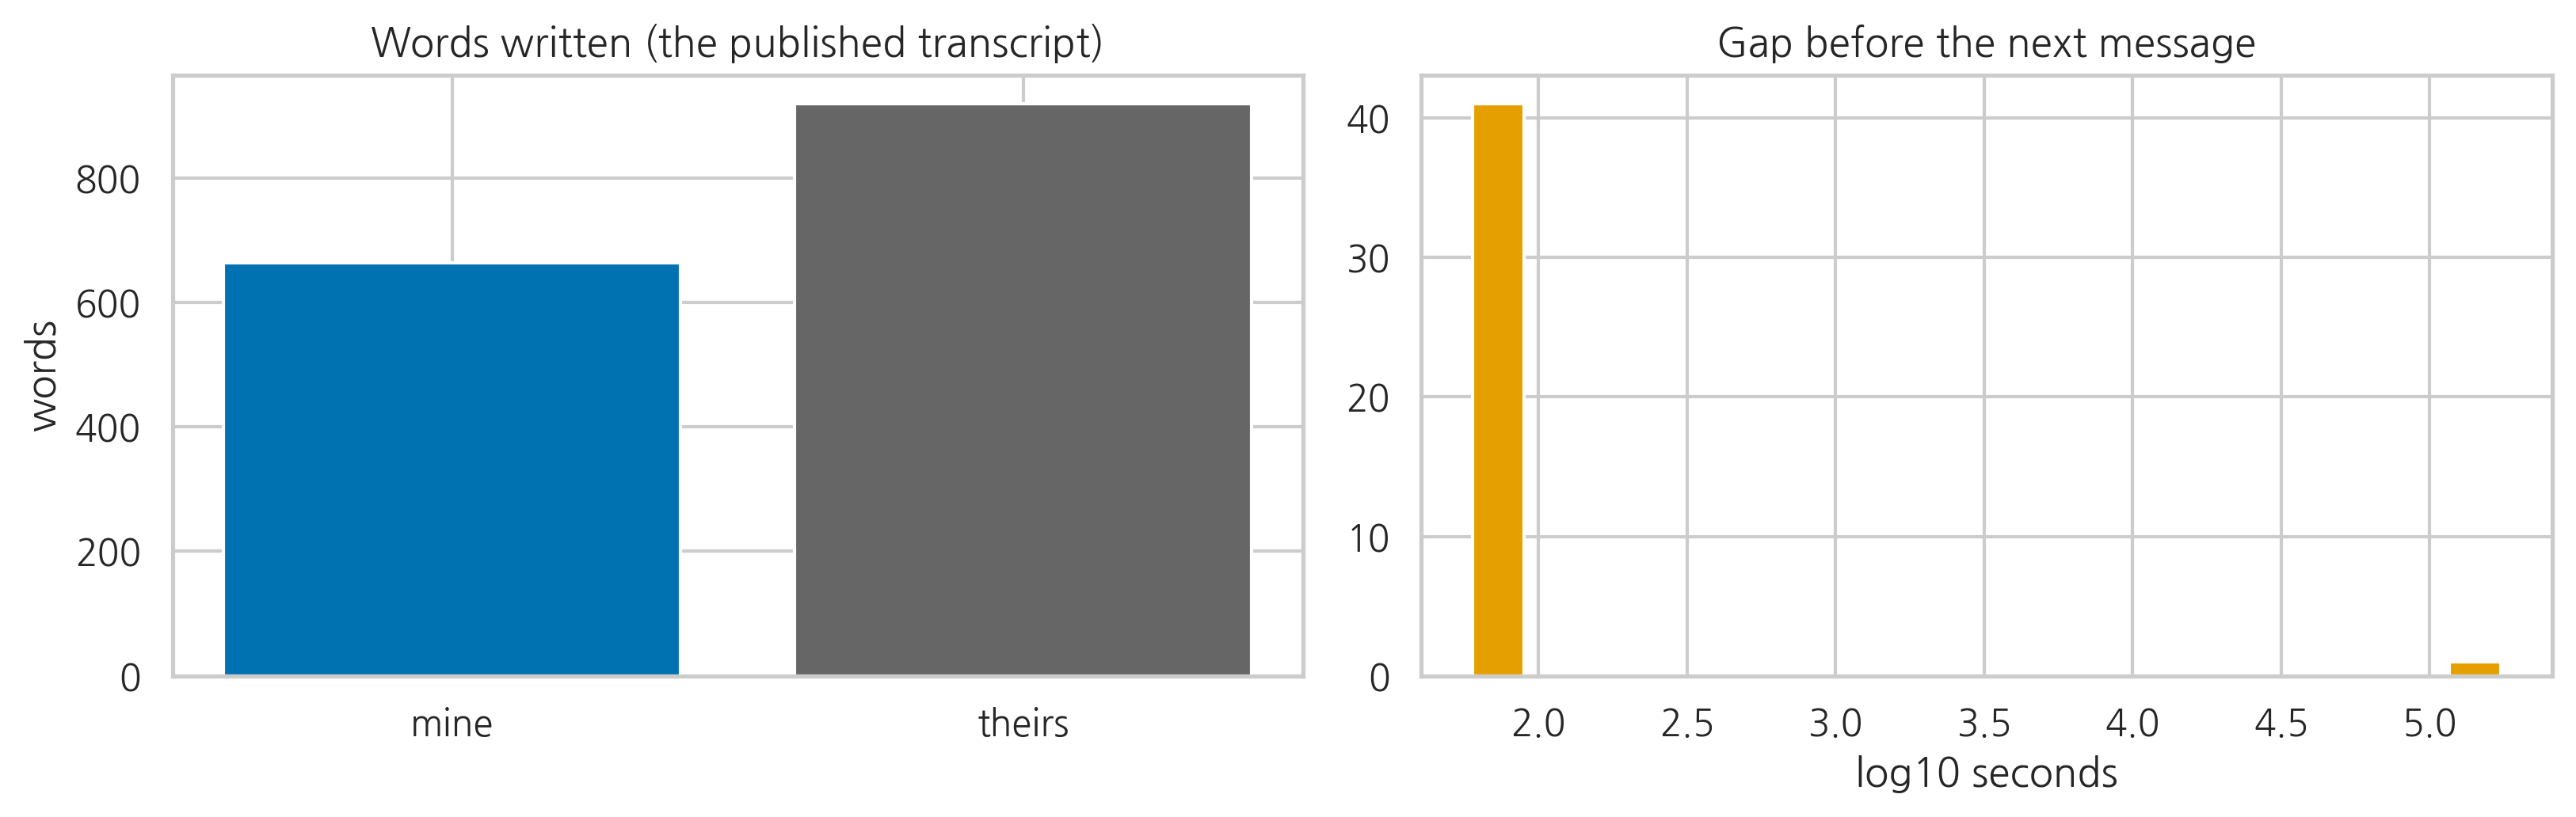

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].bar(["mine", "theirs"], [mine["words"].sum(), theirs["words"].sum()],
            color=[OKABE["blue"], OKABE["grey"]])
axes[0].set_title("Words written (" + source + ")")
axes[0].set_ylabel("words")

if len(gaps):
    axes[1].hist(np.log10(gaps.clip(lower=1)), bins=20, color=OKABE["orange"])
    axes[1].set_title("Gap before the next message")
    axes[1].set_xlabel("log10 seconds")
else:
    axes[1].text(0.5, 0.5, "no usable timestamps", ha="center", va="center",
                 transform=axes[1].transAxes, color=OKABE["grey"])
    axes[1].set_title("Gap before the next message")
    axes[1].set_xticks([])
    axes[1].set_yticks([])

plt.tight_layout()
plt.show()

**Let's look at the output.** On the published transcript, the gap before the next message comes out
as a median of 60 seconds with both quartiles also at 60, and every one of those gaps is an exact
multiple of 60 seconds.

The second line is what explains the first. This file records time to the nearest minute, so 60
seconds is the smallest gap it is capable of expressing.

| | |
|---|---|
| **What the data directly show** | Every positive gap between consecutive messages in this group is a multiple of 60 seconds, and the median and both quartiles sit at 60 |
| **A plausible interpretation** | The exchange was quick, with many replies landing within a minute of each other |
| **What this file cannot establish** | How quick. A one-second reply and a fifty-nine-second reply are recorded identically, so the distribution on screen is the clock's resolution rather than the conversation's pace |

A defensible sentence about this file is that latency is not measurable at the resolution the
question needs.

**Let's discuss.** What would the export have to record before you were willing to report a median
gap? And is there any reading of these quartiles that survives the rounding?

*Connecting to the readings.* Kaliisa and colleagues (2025) pool results across many primary
studies, and what each pooled effect size measures depends on instruments that live in the studies
it came from rather than in the meta-analysis. A rounded clock is a small version of the same
situation: the number computes cleanly, prints to two figures, and what it measures is somewhere
else.

---

## Section 3. Labelling your turns

The next cell does to you roughly what a category-building paper does to its participants. It sorts
your turns into four kinds using rules somebody else wrote, computes proportions, and prints a label
of the sort a paper would use.

**Please read this before you run it.** The label may well be uncomfortable, and that is intended
rather than accidental. It is also not a finding about you. It is the output of a keyword rule
applied to text, on a sample of one, with no validation of any kind. It has the evidential status of
the categories the discussion hour took apart, which is why it is here.

The rules are a dial. Editing them moves the label, and that is the second thing worth noticing.

**One note for the published-transcript path.** Those undergraduates were working in Spanish, and
the four rules are English keyword patterns. The output is worth reading with that in mind.

**The second count puts the other question to you.** The second half of the same cell counts how
many of your turns asked the model to justify something, name a source, or check itself. That number
is not a virtue score, it is not graded, and nobody sees it. Plenty of legitimate uses of an
assistant need no verification at all: fixing a syntax error, rephrasing a sentence, converting a
date format. The number is only worth something read next to what you were asking for at the time.

**Run the cell below.**

How my turns were sorted:

  unclassified              123   100%

Nothing was classified. That is a result about the rule, not about the person.


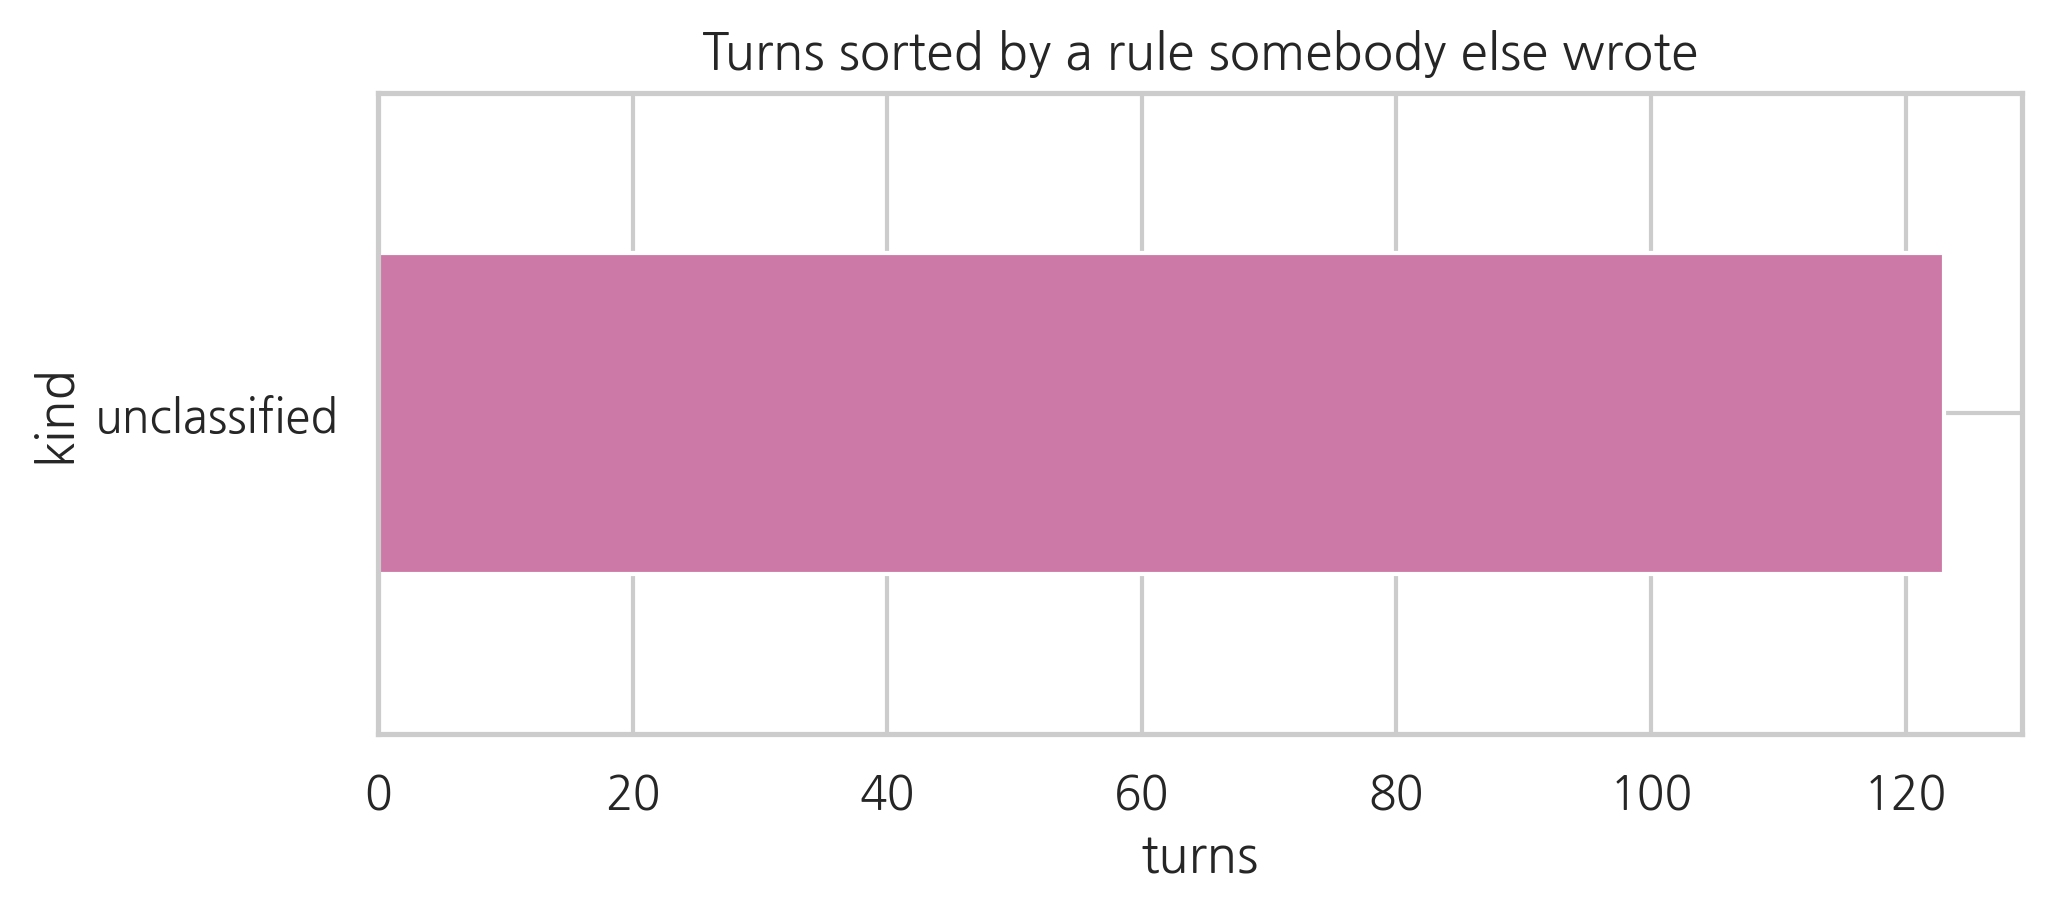


Turns of mine that ask the model to justify, cite, or check: 0 of 123 (0%)
Zero is a common result and it is a fact about how the tool got used, not about you.
Hold this next to the first count. A run of production requests with no backing requests
is a different picture from a run of fact requests with no backing requests.


In [6]:
# Your turn. These four rules construct the category. Edit them and the label moves.
RULES = {
    "asking for a fact":      r"\b(what is|who is|when did|define|meaning of|how many|which)\b",
    "asking for production":  r"\b(write|draft|generate|make|create|code|rewrite|summari[sz]e|translate)\b",
    "asking for critique":    r"\b(critique|why|is this right|check|wrong|disagree|weakness|problem with|flaw)\b",
    "asking for reassurance": r"\b(is that ok|does this make sense|am i|should i|good enough)\b",
}

NAMES = {"asking for a fact":      "a lookup-oriented user",
         "asking for production":  "a production-oriented user",
         "asking for critique":    "a critique-oriented user",
         "asking for reassurance": "a reassurance-seeking user"}


def classify(text):
    for kind, pattern in RULES.items():
        if re.search(pattern, text, re.I):
            return kind
    return "unclassified"


mine["kind"] = mine["text"].map(classify)
counts = mine["kind"].value_counts()
props = counts / counts.sum()

print("How my turns were sorted:\n")
for kind, n in counts.items():
    print("  %-24s %4d   %3.0f%%" % (kind, n, 100 * props[kind]))

named = props.drop(labels=["unclassified"], errors="ignore")
if len(named):
    top = named.idxmax()
    print("\nA paper would write: this participant is %s (%.0f%% of classified turns)."
          % (NAMES[top], 100 * named[top]))
else:
    print("\nNothing was classified. That is a result about the rule, not about the person.")

fig, ax = plt.subplots(figsize=(7, 3.2))
counts.sort_values().plot.barh(ax=ax, color=OKABE["purple"])
ax.set_title("Turns sorted by a rule somebody else wrote")
ax.set_xlabel("turns")
plt.tight_layout()
plt.show()


# Your turn. What counts as asking the model to justify, cite, or check itself.
VERIFY = r"\b(?:source|cite|citation|reference|evidence|how do you know|are you sure|double.?check|verify|is that (?:right|true|correct)|where does that come from|according to)\b"

mine["asks_for_backing"] = mine["text"].str.contains(VERIFY, case=False, regex=True)
k = int(mine["asks_for_backing"].sum())
print("\nTurns of mine that ask the model to justify, cite, or check: %d of %d (%.0f%%)"
      % (k, len(mine), 100 * k / max(len(mine), 1)))
if k == 0:
    print("Zero is a common result and it is a fact about how the tool got used, not about you.")
print("Hold this next to the first count. A run of production requests with no backing requests\n"
      "is a different picture from a run of fact requests with no backing requests.")

**Let's look at the output.** On the published transcript the rule reports 100 percent unclassified
across all 123 of the selected author's turns, and the verification count comes out at 0 of 123.

Neither result is a bug in the notebook, and neither is hidden. What is worth sitting with is the
form it took: the instrument did not report that it could not classify this language. It returned
zeros, in the same layout, looking as authoritative as it did before.

| | |
|---|---|
| **What the data directly show** | None of the 123 turns matched any of the four English keyword patterns, and none matched the verification pattern |
| **A plausible interpretation** | The rule was written in one language and applied to a conversation in another, so the zeros describe the rule's reach |
| **What this run cannot establish** | What these students were in fact asking each other for. A Spanish-language rule, or a person reading the turns, would be needed for that, and neither is in this notebook |

**Let's discuss.** One pattern worth noticing is that a rule matching nothing and a person asking for
nothing produce the same printed output. What are some plausible explanations for a zero in a
category count, and what additional information would let you tell them apart? If you are on your
own log and the verification count is low, the same question applies: what would distinguish "did
not ask" from "the rule did not match the way I asked"?

Zero here is a fact about how a tool got used and about how a rule was written. Reading it as a
result about a person would require evidence that neither count contains.

*Connecting to the readings.* Yang and colleagues (2022) sort participants before the analysis
begins, using an instrument with a cutoff and a norming population, and the reading questions this
week ask what each of those three things was. The label printed above was produced the same way,
without any of that care: a rule somebody wrote in an afternoon, a threshold at "any match", and a
population of one. It may be useful to ask what the paper's sorting operation has that this one does
not, and whether the difference is one of kind or of degree.

---

## Section 4. Arguing against the label

This is the deliverable of the session, and it is not collected.

Please write three things the label gets wrong. For each one, name the evidence that would settle it,
and say whether that evidence is anywhere in the trace. It may be worth marking which of the three a
better export would reach and which no export would.

Then a question worth answering in writing rather than in your head:

> The students in Yang and colleagues (2022) knew all of this about themselves too, and nobody asked
> them. **What follows for a study you are about to run?**

If you are on the published-transcript path, please write it about the busiest author in that group,
and say what changes when the person being described is somebody you have never met.

*Connecting to the readings.* Koretsky and colleagues (2021) compare processes in groups whose
outcomes were already known when the analysis began, and the reading questions ask what such a
comparison can and cannot establish. The same question fits the cell above: the label was assigned
after the turns were written, by a rule with no access to why any of them were written.

### Your answer

*Double-click this cell to edit it. Delete this line and write here. It stays on your machine.*

**Three things the label gets wrong, and what would settle each:**

1.
2.
3.

**What follows for my own study:**

---

## Going further (optional)

Everything below is optional and not needed today. Please feel free to stop here.

### Pointing the notebook at a different person

`load_published_transcript` makes two selections: it keeps the group with the most recorded
messages, and inside it labels `me` whichever author posted the most messages. Replacing
`df["Group"].value_counts().idxmax()` with `df["Group"].value_counts().index[1]` in the Section 1
cell, and re-running from there, gives a different person in a different group, whose share of the
words is about 25 percent rather than about 42. Nothing about the file changed.

### Moving the dial on the rules

`RULES` in Section 3 is four regular expressions, and `classify` returns on the first one that
matches, so their order is part of the instrument. A turn beginning "why is this wrong" can match
more than one pattern. It may be useful to ask what a paper would have to report about rule order
before a reader could reproduce its categories.

### The language question

Translating one of the four rules into Spanish and re-running on the published transcript will move
the unclassified proportion off 100 percent. What that new number would need before it could be
reported is a good question to sit with, and it is the question a multilingual corpus puts to every
text-analytic method in this course.

### Turns you would have classified differently

`mine[["kind", "text"]].sample(10)` prints a sample of turns next to the label the rule gave them.
Reading them and marking where you disagree is a cheap validity check, and roughly what a paper
reports as inter-rater agreement, on a sample of one rater.

---

## Before December 2

Your project has a category in it. Every project does: a group you compare, a population you bound,
a threshold you pick, a set of studies you pool.

Before you present, it may be useful to be able to say in one sentence each where the category came
from, what in your argument would not survive without it, and which two people it would treat as the
same.

That last one is the move this course has returned to since Week 3, and it is one a committee tends
to ask about.

### Before you leave today

- [ ] I ran the cells in this notebook and saw the output.
- [ ] I can say what one row of the turns table represents, and what it leaves out.
- [ ] I can explain why a count of zero in a category is not yet a finding about a person.
- [ ] I wrote something in the Section 4 cell, and it is staying with me.

### A note on AI use

There is nothing from this notebook to upload, and nothing here is collected. If you used an
assistant today to make sense of a line of code or a regular expression, that exchange belongs in
the AI interaction log for your final project, in the form you have used since Week 4: the full
conversation record in a Word file attached to the Canvas submission, and the four syllabus
questions answered in the Canvas text box.

Today is a reasonable moment to look at what a semester of those logs holds, since you are the only
person who has all of them.